In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

> Load the dataset

In [3]:
df = pd.read_csv('Medical Insurance Dataset.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
3033,32,female,17.765,2,yes,northwest,32734.18630
3034,38,male,34.700,2,no,southwest,6082.40500
3035,59,female,26.505,0,no,northeast,12815.44495
3036,61,female,22.040,0,no,northeast,13616.35860


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3038 entries, 0 to 3037
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       3038 non-null   int64  
 1   sex       3038 non-null   object 
 2   bmi       3038 non-null   float64
 3   children  3038 non-null   int64  
 4   smoker    3038 non-null   object 
 5   region    3038 non-null   object 
 6   charges   3038 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 166.3+ KB


> Data cleaning and preprocessing:

In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
for col in df.select_dtypes(include=['object']):
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts())


Unique values in sex:
sex
male      1533
female    1505
Name: count, dtype: int64

Unique values in smoker:
smoker
no     2405
yes     633
Name: count, dtype: int64

Unique values in region:
region
southeast    834
southwest    746
northwest    739
northeast    719
Name: count, dtype: int64


In [7]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1}) #Convert 'sex' and 'smoker' to numerical values


In [8]:
df.describe()

,age,sex,bmi,children,smoker,charges
count,3038.000000,3038.000000,3038.000000,3038.000000,3038.000000,3038.000000
mean,39.089862,0.504608,30.700265,1.098749,0.208361,13335.661423
std,14.121217,0.500061,6.085241,1.215146,0.406203,12209.554407
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,26.000000,0.000000,26.315000,0.000000,0.000000,4676.641325
50%,39.000000,1.000000,30.400000,1.000000,0.000000,9391.346000
75%,51.000000,1.000000,34.800000,2.000000,0.000000,16862.795985
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010


> we check for missing values, examine unique values in categorical columns, convert 'sex' and 'smoker' to numerical values, and create dummy variables for the 'region' column. This prepares our data for analysis and modeling.

> Exploratory Data Analysis and Visualizations:
  1. Distribution of insurance charges

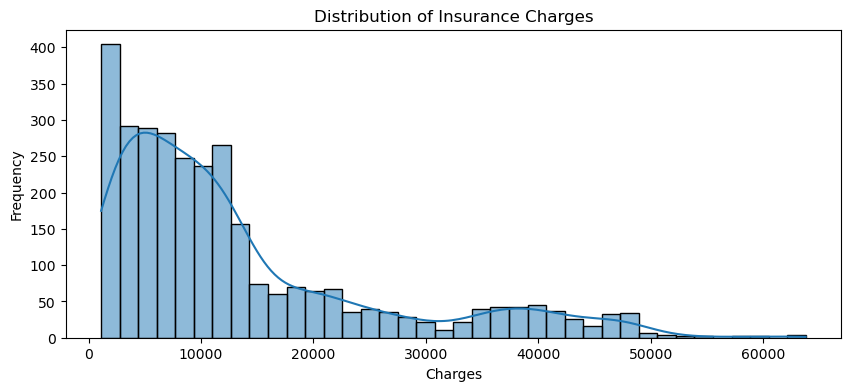

In [9]:
plt.figure(figsize=(10, 4))
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

> 2. Relationship between age and charges

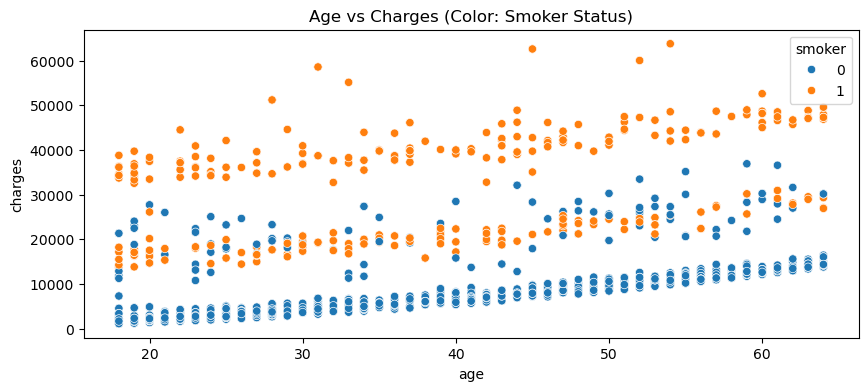

In [10]:
plt.figure(figsize=(10, 4))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title('Age vs Charges (Color: Smoker Status)')
plt.show()


> 3.BMI vs Charges

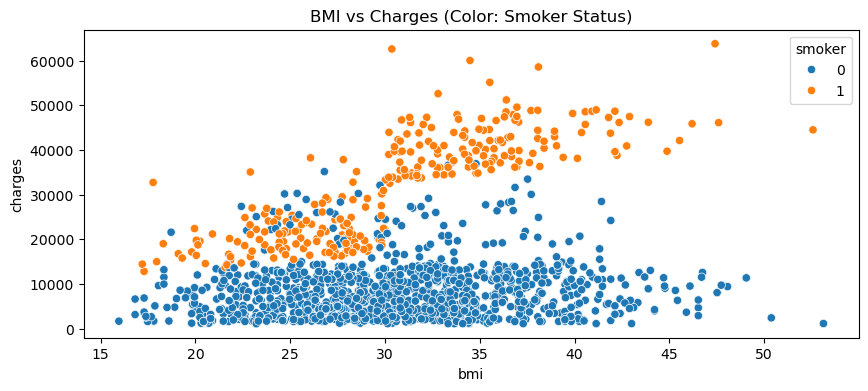

In [11]:
plt.figure(figsize=(10, 4))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('BMI vs Charges (Color: Smoker Status)')
plt.show()

> 4. Average charges by region

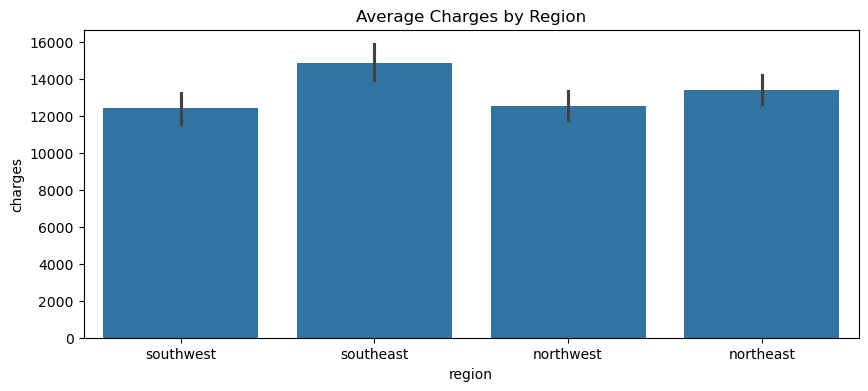

In [12]:
plt.figure(figsize=(10, 4))
sns.barplot(x='region', y='charges', data=df)
plt.title('Average Charges by Region')
plt.show()

In [13]:
df = pd.get_dummies(df, columns=['region'], prefix='region')

In [14]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='object')

In [15]:
# Prepare data for modeling
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']]
y = df['charges']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

# Print feature importances
for feature, importance in zip(X.columns, model.coef_):
    print(f"{feature}: {importance}")

Mean Squared Error: 37291728.247663975
R-squared Score: 0.7470597117860042
age: 257.9325005900847
sex: 32.09627907966295
bmi: 344.0964890621606
children: 465.1907175272623
smoker: 23804.681750080195
region_northwest: -560.2005871777903
region_southeast: -1242.3677866424032
region_southwest: -1102.6487864099806


> > Summary and Insights:

In [16]:
print("\nSummary Statistics:")
print(f"Average Insurance Charge: ${df['charges'].mean():.2f}")
print(f"Median Insurance Charge: ${df['charges'].median():.2f}")
print(f"Minimum Insurance Charge: ${df['charges'].min():.2f}")
print(f"Maximum Insurance Charge: ${df['charges'].max():.2f}")

print(f"\nPercentage of Smokers: {(df['smoker'].mean() * 100):.2f}%")
print(f"Average Age: {df['age'].mean():.2f} years")
print(f"Average BMI: {df['bmi'].mean():.2f}")

print("\nTop 3 Factors Influencing Insurance Charges:")
top_factors = sorted(zip(X.columns, abs(model.coef_)), key=lambda x: x[1], reverse=True)[:3]
for factor, importance in top_factors:
    print(f"{factor}: {importance:.2f}")


Summary Statistics:
Average Insurance Charge: $13335.66
Median Insurance Charge: $9391.35
Minimum Insurance Charge: $1121.87
Maximum Insurance Charge: $63770.43

Percentage of Smokers: 20.84%
Average Age: 39.09 years
Average BMI: 30.70

Top 3 Factors Influencing Insurance Charges:
smoker: 23804.68
region_southeast: 1242.37
region_southwest: 1102.65
